# Artifact Investigation: Histone / OXPHOS / Ribosomal Gene Signatures

Investigates why these gene families appear as cross-disease GSEA hits and whether their anomaly signals are biological or technical artifacts.

**Analysis plan**
1. Cross-disease prevalence of histone/OXPHOS/ribo GSEA terms
2. HC detectability and branch assignment for these gene families
3. HC Z-score calibration check (model correctness)
4. Disease Z-score distributions and systematic shifts
5. Root cause: study-level batch confounding
6. Cross-disease gene ubiquity quantification
7. Proposed improvements: ubiquity filter + recalibration strategies

In [36]:
import glob
import os
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
modeling_dir = str(Path.cwd())
if modeling_dir not in sys.path:
    sys.path.insert(0, modeling_dir)

import config
from pipeline import data_prep
from viz_style import apply_style
apply_style()

In [37]:
adata = data_prep.load_adata()
is_hc, phenos, _ = data_prep.make_phenotypes(adata)

Z_dis_raw = np.load(config.Z_DISEASE)
Z_hc_raw = np.load(config.Z_HC)
gene_ids = np.load(config.Z_GENE_NAMES, allow_pickle=True)
dis_names = np.load(config.Z_SAMPLE_NAMES, allow_pickle=True).tolist()
hc_names = np.load(config.Z_HC_NAMES, allow_pickle=True).tolist()

Z_dis, _ = data_prep.clean_z(Z_dis_raw)
Z_hc, _ = data_prep.clean_z(Z_hc_raw)

id2sym = dict(zip(adata.var.index, adata.var['GeneName']))
gene_syms = np.array([id2sym.get(g, g) for g in gene_ids])
sym2idx = {s: i for i, s in enumerate(gene_syms)}

dis_obs = adata.obs[~is_hc].copy()
dis_obs['pheno'] = phenos[~is_hc]
hc_obs = adata.obs[is_hc].copy()

name2pheno = dict(zip(dis_obs.index, dis_obs['pheno']))
name2author_dis = dict(zip(dis_obs.index, dis_obs['Author']))
name2author_hc = dict(zip(hc_obs.index, hc_obs['Author']))

dis_pheno = np.array([name2pheno.get(n, 'Unknown') for n in dis_names])
dis_author = np.array([name2author_dis.get(n, '?') for n in dis_names])
hc_author = np.array([name2author_hc.get(n, '?') for n in hc_names])

X_all = data_prep.bias_matrix(adata)
X_hc = X_all[is_hc]
X_dis_all = X_all[~is_hc]
obs_dis_order = {n: i for i, n in enumerate(dis_obs.index.tolist())}
dis_order = [obs_dis_order[n] for n in dis_names if n in obs_dis_order]
X_dis = X_dis_all[dis_order]

ts = pd.read_csv(config.ENGINE_DIR / 'training_summary.csv')
ts['sym'] = [id2sym.get(g, g) for g in ts['gene']]

print(f'Z_dis: {Z_dis.shape}   Z_hc: {Z_hc.shape}   genes: {len(gene_syms)}')
print(f'Disease phenotypes: {len(np.unique(dis_pheno[dis_pheno != "Unknown"]))}')
print(f'HC studies: {len(np.unique(hc_author))}')

Z_dis: (913, 20097)   Z_hc: (693, 20097)   genes: 20097
Disease phenotypes: 25
HC studies: 9


In [38]:
HISTONE_PAT = re.compile(r'^HIST[0-9]|^H[0-9][A-Z][A-Z0-9]|^H[0-9]-', re.I)
RIBO_PAT = re.compile(r'^RPS[0-9]|^RPL[0-9]|^RPLP')
MITO_MT_PAT = re.compile(r'^MT-')
OXPHOS_PAT = re.compile(r'^NDUF|^COX[0-9]|^ATP5|^UQCR|^CYC|^SDHA|^SDHB|^SDHC|^SDHD')

def classify_sym(s):
    if MITO_MT_PAT.match(s):
        return 'mito_MT'
    if OXPHOS_PAT.match(s):
        return 'oxphos'
    if HISTONE_PAT.match(s):
        return 'histone'
    if RIBO_PAT.match(s):
        return 'ribo'
    return 'other'

gene_cat = np.array([classify_sym(s) for s in gene_syms])
cat_idx = {c: np.where(gene_cat == c)[0] for c in np.unique(gene_cat)}

for cat, idx in sorted(cat_idx.items()):
    print(f'{cat:12s}: {len(idx):4d} genes  examples: {gene_syms[idx[:4]].tolist()}')

histone     :   96 genes  examples: ['H6PD', 'H2BW2', 'H2AZ2', 'H2BW1']
mito_MT     :   13 genes  examples: ['MT-ND6', 'MT-CO2', 'MT-CYB', 'MT-ND2']
other       : 19775 genes  examples: ['TSPAN6', 'TNMD', 'DPM1', 'SCYL3']
oxphos      :  113 genes  examples: ['NDUFAF7', 'NDUFAB1', 'COX10', 'UQCRC1']
ribo        :  100 genes  examples: ['RPS20', 'RPL26L1', 'RPL18', 'RPL31']


## Section 1: Cross-disease prevalence of artifact GSEA pathways

Count how many diseases have significant GSEA terms in histone/OXPHOS/ribo categories, and inspect which direction (NES sign).

In [39]:
GSEA_PATTERNS = {
    'histone':  re.compile(r'histone|chromatin|nucleosome', re.I),
    'oxphos':   re.compile(r'mitochond|oxidative phosph|electron transport|respiratory chain|complex I|complex III|complex IV', re.I),
    'ribo':     re.compile(r'ribosom|rRNA|translation elongation|translation initiation', re.I),
}

gsea_files = sorted(glob.glob(str(config.GSEA_DIR / 'gsea_result_*.csv')))
n_diseases = len(gsea_files)

gsea_summary = []
lead_genes_by_cat = defaultdict(lambda: defaultdict(set))

for f in gsea_files:
    disease = Path(f).stem.replace('gsea_result_', '')
    df = pd.read_csv(f)
    row = {'disease': disease, 'total_sig': len(df)}
    for cat, pat in GSEA_PATTERNS.items():
        hits = df[df['Term'].str.contains(pat, na=False)]
        row[f'{cat}_n'] = len(hits)
        pos = hits[hits['NES'] > 0]
        neg = hits[hits['NES'] < 0]
        row[f'{cat}_pos'] = len(pos)
        row[f'{cat}_neg'] = len(neg)
        for leads in hits['Lead_genes'].dropna():
            lead_genes_by_cat[cat][disease].update(str(leads).split(';'))
    gsea_summary.append(row)

gsea_df = pd.DataFrame(gsea_summary)
print(f'N disease phenotypes in GSEA: {n_diseases}')
print()
for cat in GSEA_PATTERNS:
    n_sig = (gsea_df[f'{cat}_n'] > 0).sum()
    print(f'{cat:10s}: significant in {n_sig}/{n_diseases} diseases  '
          f'(pos NES: {(gsea_df[f"{cat}_pos"]>0).sum()}, neg NES: {(gsea_df[f"{cat}_neg"]>0).sum()})')

N disease phenotypes in GSEA: 22

histone   : significant in 22/22 diseases  (pos NES: 9, neg NES: 15)
oxphos    : significant in 21/22 diseases  (pos NES: 8, neg NES: 16)
ribo      : significant in 21/22 diseases  (pos NES: 6, neg NES: 19)


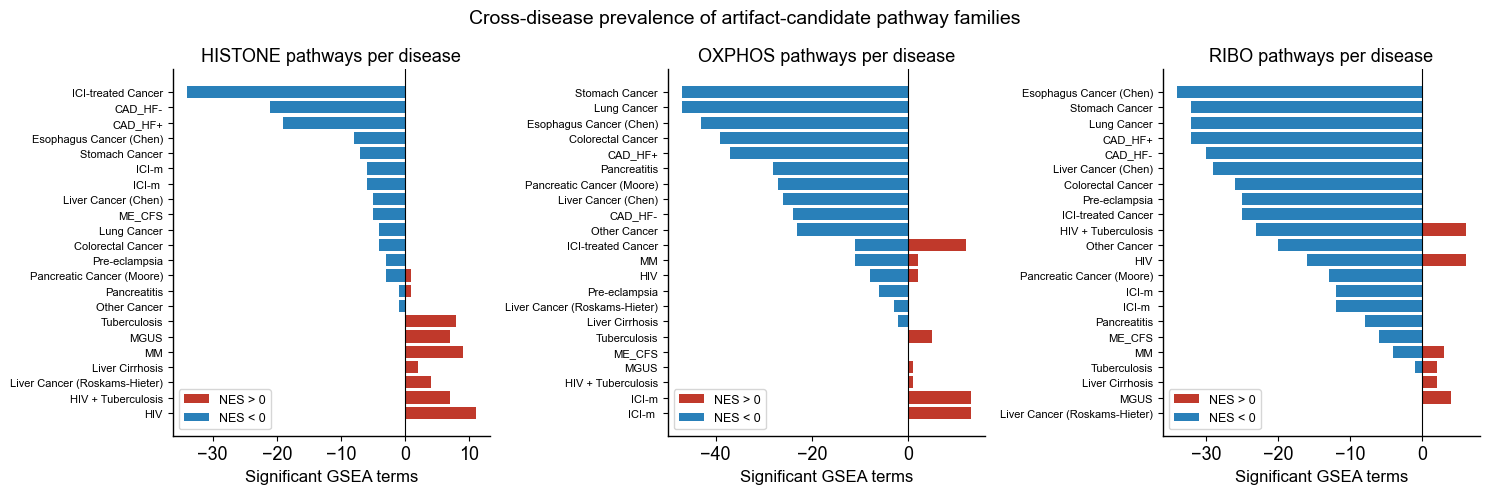

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cat in zip(axes, GSEA_PATTERNS):
    sub = gsea_df[['disease', f'{cat}_pos', f'{cat}_neg']].set_index('disease')
    sub = sub.sort_values(f'{cat}_neg', ascending=True)
    colors_pos = '#c0392b'
    colors_neg = '#2980b9'
    ax.barh(sub.index, sub[f'{cat}_pos'], color=colors_pos, label='NES > 0')
    ax.barh(sub.index, -sub[f'{cat}_neg'], color=colors_neg, label='NES < 0')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{cat.upper()} pathways per disease', fontsize=13)
    ax.set_xlabel('Significant GSEA terms', fontsize=12)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=9)

fig.suptitle('Cross-disease prevalence of artifact-candidate pathway families', fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
print('=== Lead genes appearing in >= 50% of diseases (cross-disease ubiquitous drivers) ===')
for cat in GSEA_PATTERNS:
    gene_count = Counter()
    for genes in lead_genes_by_cat[cat].values():
        gene_count.update(genes)
    threshold = n_diseases * 0.5
    ubiq = [(g, c) for g, c in gene_count.most_common(15) if c >= threshold]
    print(f'\n{cat.upper()} — top ubiquitous lead genes:')
    for g, c in ubiq:
        print(f'  {g:12s}: {c}/{n_diseases} ({c/n_diseases*100:.0f}%)')

=== Lead genes appearing in >= 50% of diseases (cross-disease ubiquitous drivers) ===

HISTONE — top ubiquitous lead genes:
  H2BC21      : 13/22 (59%)
  H2AC4       : 13/22 (59%)
  H2AC7       : 13/22 (59%)
  H2AC11      : 13/22 (59%)
  PSMA5       : 12/22 (55%)
  H2BC9       : 12/22 (55%)
  H2AC14      : 12/22 (55%)
  H3C7        : 12/22 (55%)
  H2AC12      : 12/22 (55%)
  PSMB8       : 12/22 (55%)
  SMARCA5     : 12/22 (55%)
  H2AZ2       : 11/22 (50%)
  SKP1        : 11/22 (50%)
  H2BC13      : 11/22 (50%)
  PSME2       : 11/22 (50%)

OXPHOS — top ubiquitous lead genes:
  NDUFA1      : 17/22 (77%)
  UQCRH       : 16/22 (73%)
  ATP5ME      : 16/22 (73%)
  NDUFB3      : 16/22 (73%)
  NDUFB2      : 16/22 (73%)
  ATP6V1G1    : 15/22 (68%)
  COX6C       : 15/22 (68%)
  COX7A2      : 15/22 (68%)
  NDUFA5      : 15/22 (68%)
  NDUFS7      : 15/22 (68%)
  NDUFC1      : 15/22 (68%)
  PET100      : 15/22 (68%)
  ATP6V1F     : 15/22 (68%)
  NDUFA10     : 14/22 (64%)
  UQCRHL      : 14/22 (64%)

## Section 2: HC detectability and branch assignment

Confirm that these gene families are high-detectability genes going through the NBI branch, so the systematic Z-shift is not a logistic-branch artifact.

=== Detection rate summary by gene category ===
           count   mean    std    min    25%    50%    75%  max
cat                                                            
histone     93.0  0.735  0.343  0.010  0.625  0.925  0.980  1.0
mito_MT     13.0  1.000  0.001  0.999  1.000  1.000  1.000  1.0
other    19221.0  0.613  0.368  0.010  0.215  0.763  0.962  1.0
oxphos     112.0  0.897  0.225  0.014  0.937  0.986  0.994  1.0
ribo        99.0  0.938  0.194  0.026  0.994  1.000  1.000  1.0

=== Branch assignment by category ===
branch   logistic    nbi
cat                     
histone     0.129  0.871
mito_MT     0.000  1.000
other       0.153  0.847
oxphos      0.036  0.964
ribo        0.020  0.980


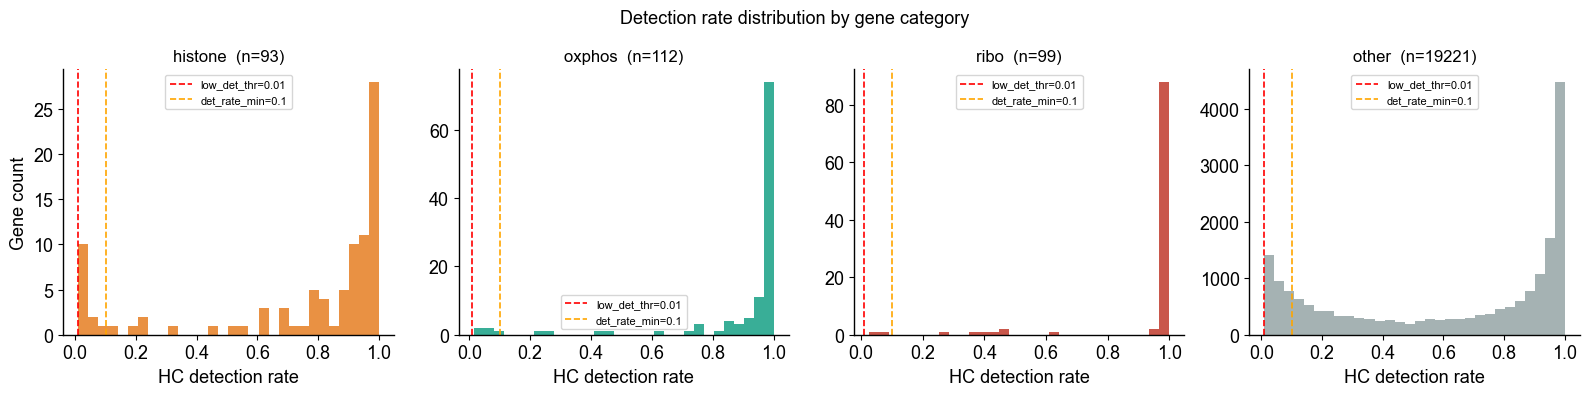

In [42]:
ts['cat'] = ts['sym'].map(classify_sym)

print('=== Detection rate summary by gene category ===')
print(ts.groupby('cat')['det_rate'].describe().round(3))

print()
print('=== Branch assignment by category ===')
print(pd.crosstab(ts['cat'], ts['branch'], normalize='index').round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
cat_colors = {'histone': '#e67e22', 'mito_MT': '#8e44ad', 'oxphos': '#16a085', 'ribo': '#c0392b', 'other': '#95a5a6'}
cats_show = ['histone', 'oxphos', 'ribo', 'other']

for ax, cat in zip(axes, cats_show):
    sub = ts[ts['cat'] == cat]['det_rate']
    ax.hist(sub, bins=30, color=cat_colors.get(cat, '#95a5a6'), edgecolor='none', alpha=0.85)
    ax.axvline(config.MODELING_PARAMS['low_det_thr'], color='red', linewidth=1.2, linestyle='--', label=f'low_det_thr={config.MODELING_PARAMS["low_det_thr"]}')
    ax.axvline(config.MODELING_PARAMS['det_rate_min'], color='orange', linewidth=1.2, linestyle='--', label=f'det_rate_min={config.MODELING_PARAMS["det_rate_min"]}')
    ax.set_title(f'{cat}  (n={len(sub)})', fontsize=12)
    ax.set_xlabel('HC detection rate')
    if cat == cats_show[0]:
        ax.set_ylabel('Gene count')
    ax.legend(fontsize=8)

plt.suptitle('Detection rate distribution by gene category', fontsize=13)
plt.tight_layout()
plt.show()

## Section 3: HC Z-score calibration check

If the NBI model is correctly calibrated, HC Z-scores should be N(0,1) for all gene categories. A well-calibrated model rules out model misspecification as the root cause.

=== HC Z-score calibration (model is valid if mean~0, std~1, |z|>3 ~0.27%) ===
histone   : mean=0.0066  std=0.9939  |z|>3=0.57%  (n_genes=96)
oxphos    : mean=0.0036  std=1.0079  |z|>3=0.61%  (n_genes=113)
ribo      : mean=0.0029  std=0.9993  |z|>3=0.49%  (n_genes=100)
other     : mean=0.0030  std=0.9954  |z|>3=0.42%  (n_genes=19775)


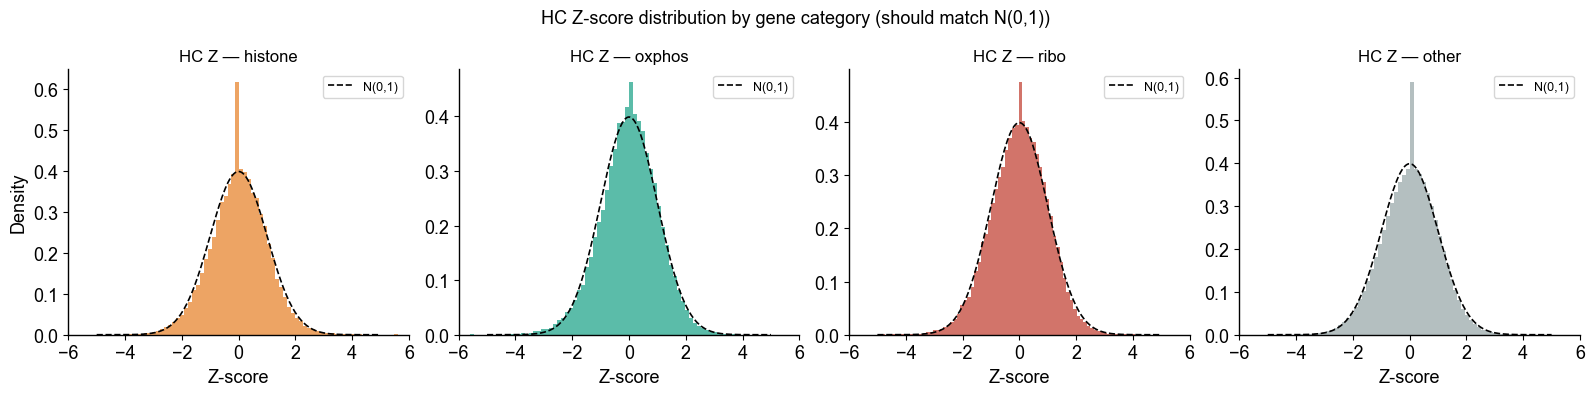

In [43]:
print('=== HC Z-score calibration (model is valid if mean~0, std~1, |z|>3 ~0.27%) ===')
for cat in cats_show:
    idx = cat_idx[cat]
    z = Z_hc[:, idx].ravel()
    z = z[np.isfinite(z)]
    pct3 = (np.abs(z) > 3).mean() * 100
    print(f'{cat:10s}: mean={z.mean():.4f}  std={z.std():.4f}  |z|>3={pct3:.2f}%  (n_genes={len(idx)})')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x_ref = np.linspace(-5, 5, 200)

for ax, cat in zip(axes, cats_show):
    idx = cat_idx[cat]
    z = Z_hc[:, idx].ravel()
    z = z[np.isfinite(z)]
    ax.hist(z, bins=80, density=True, color=cat_colors.get(cat, '#95a5a6'), alpha=0.7, edgecolor='none')
    ax.plot(x_ref, norm.pdf(x_ref), 'k--', linewidth=1.2, label='N(0,1)')
    ax.set_xlim(-6, 6)
    ax.set_title(f'HC Z — {cat}', fontsize=12)
    ax.set_xlabel('Z-score')
    if cat == cats_show[0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('HC Z-score distribution by gene category (should match N(0,1))', fontsize=13)
plt.tight_layout()
plt.show()

=== HC study-level mean Z for core OXPHOS and ribo genes ===
  (HC Z-scores should be ~0 in every study if batch is fully captured by BIAS_COLUMNS)

                           n  RPS20  RPL11  NDUFA1  ATP5ME  UQCRH  COX7A2
study                                                                    
Chang et al.              78  0.290  0.203  -0.358  -0.471 -0.483  -0.043
Chen et al.               31 -0.096 -0.762  -0.684  -0.614 -0.639  -0.756
Gardella et al.           73 -0.227 -0.395   0.096  -0.235  0.166  -0.246
Moore et al.             104 -0.660 -0.441  -0.274  -0.425 -0.447  -0.273
Moufarrej et al.         194  0.004  0.018   0.155   0.323  0.162   0.066
Reggiardo et al.          17  0.568  0.160   1.276   0.415  0.653   1.086
Roskams-Hieter B et al.   30  0.568  0.414  -0.806  -0.126 -0.782  -0.127
Tuni et al.               50  0.915  0.547   0.132   0.257  0.292   0.269
Ward Z et al.            116 -0.063  0.272   0.310   0.324  0.457   0.256


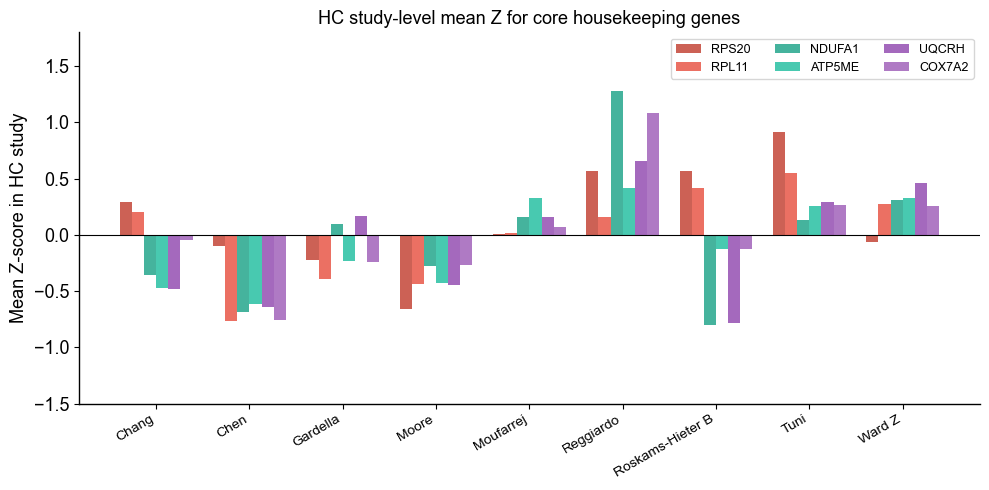

In [44]:
print('=== HC study-level mean Z for core OXPHOS and ribo genes ===')
print('  (HC Z-scores should be ~0 in every study if batch is fully captured by BIAS_COLUMNS)')
print()

core_genes = ['RPS20', 'RPL11', 'NDUFA1', 'ATP5ME', 'UQCRH', 'COX7A2']
core_idx_list = [sym2idx[g] for g in core_genes if g in sym2idx]

hc_study_df = []
for study in sorted(np.unique(hc_author)):
    m = hc_author == study
    row = {'study': study, 'n': m.sum()}
    for g, idx in zip(core_genes, core_idx_list):
        row[g] = float(Z_hc[m, idx].mean())
    hc_study_df.append(row)

hc_study_df = pd.DataFrame(hc_study_df).set_index('study')
print(hc_study_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(hc_study_df))
width = 0.13
colors_bar = ['#c0392b','#e74c3c','#16a085','#1abc9c','#8e44ad','#9b59b6']
for i, (g, col) in enumerate(zip(core_genes, colors_bar)):
    ax.bar(x + i * width, hc_study_df[g].values, width, label=g, color=col, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([s.split(' et')[0] for s in hc_study_df.index], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mean Z-score in HC study')
ax.set_title('HC study-level mean Z for core housekeeping genes', fontsize=13)
ax.legend(fontsize=9, ncol=3)
ax.set_ylim(-1.5, 1.8)
plt.tight_layout()
plt.show()

## Section 4: Disease Z-score distribution and root cause

**Finding from Section 3**: HC Z-scores are well-calibrated globally, but within individual HC studies, mean Z deviates substantially from 0 for OXPHOS and ribo genes (range: -0.8 to +1.3). This study-level residual variance is not captured by BIAS_COLUMNS.

Here we confirm: (a) disease samples show systematic negative Z for OXPHOS/ribo, and (b) this shift is driven primarily by study-of-origin, not phenotype.

In [45]:
print('=== Disease study-level mean Z for core genes ===')
print()

dis_study_df = []
for study in sorted(np.unique(dis_author)):
    m = dis_author == study
    phs = np.unique(dis_pheno[m])
    row = {'study': study, 'n': m.sum(), 'phenotypes': ','.join(sorted(phs))[:50]}
    for g, idx in zip(core_genes, core_idx_list):
        row[g] = float(Z_dis[m, idx].mean())
    dis_study_df.append(row)

dis_study_df = pd.DataFrame(dis_study_df).set_index('study')
print(dis_study_df[['n'] + core_genes].round(3).to_string())

print()
print('=== ANOVA: does study explain Z-score variation in disease? ===')
for g, idx in zip(core_genes, core_idx_list):
    z = Z_dis[:, idx]
    groups = [z[dis_author == s] for s in np.unique(dis_author) if (dis_author == s).sum() > 1]
    f, p = stats.f_oneway(*groups)
    eta2 = (f * (len(groups) - 1)) / (f * (len(groups) - 1) + len(z) - len(groups))
    print(f'{g}: F={f:.1f}  p={p:.1e}  eta2={eta2:.3f}')

=== Disease study-level mean Z for core genes ===

                           n  RPS20  RPL11  NDUFA1  ATP5ME  UQCRH  COX7A2
study                                                                    
Block et al.               5 -0.391 -1.161  -0.841  -0.838 -0.378  -1.685
Chang et al.             127 -0.164 -0.155  -0.152  -0.490 -0.003   0.098
Chen et al.              145 -1.249 -1.273  -1.335  -1.342 -1.251  -1.616
Gardella et al.           90 -0.343 -0.347  -0.085  -0.283  0.190  -0.130
Moore et al.             173 -0.405 -0.378  -0.457  -0.646 -0.670  -0.446
Moufarrej et al.          62 -0.225 -0.232   0.092   0.065  0.084  -0.229
Peddu et al.               1  1.369  3.267   1.035   0.160  0.702   1.077
Raissadati et al.         22 -2.785 -1.754   3.174   1.483  3.724   2.298
Reggiardo et al.           6 -0.313 -1.545   1.888  -0.152  1.516   1.675
Roskams-Hieter B et al.   58 -0.153 -0.080  -0.786  -0.356 -1.090  -0.328
Ward Z et al.            224 -1.539 -1.904  -0.713  -1.056 -1

In [46]:
print('=== Residual correlation of Z with BIAS_COLUMNS after NBI conditioning ===')
print('  (Should be ~0 if BIAS_COLUMNS fully explain the variation)')
print()
for g, idx in zip(core_genes[:4], core_idx_list[:4]):
    z = Z_dis[:, idx]
    rs = []
    for j, col in enumerate(config.BIAS_COLUMNS):
        r, p = stats.pearsonr(X_dis[:, j], z)
        rs.append((col, r, p))
    rs_sig = [(col, r, p) for col, r, p in rs if p < 0.05]
    rs_sig.sort(key=lambda x: abs(x[1]), reverse=True)
    print(f'{g}:')
    for col, r, p in rs_sig[:4]:
        print(f'  {col:38s}: r={r:.3f}  p={p:.2e}')
    print()

=== Residual correlation of Z with BIAS_COLUMNS after NBI conditioning ===
  (Should be ~0 if BIAS_COLUMNS fully explain the variation)

RPS20:
  NG80                                  : r=0.343  p=1.35e-26
  RNA Degradation (3' Bias)             : r=0.323  p=1.50e-23
  Gene Length Bias                      : r=0.242  p=1.14e-13
  gDNA Contamination (Intron/Exon)      : r=0.214  p=6.42e-11

RPL11:
  NG80                                  : r=0.403  p=6.40e-37
  Gene Length Bias                      : r=0.347  p=2.80e-27
  RNA Degradation (3' Bias)             : r=0.327  p=3.34e-24
  log(Total Reads)                      : r=0.278  p=1.21e-17

NDUFA1:
  NG80                                  : r=0.316  p=1.26e-22
  GC Bias                               : r=-0.295  p=9.40e-20
  RNA Degradation (3' Bias)             : r=-0.172  p=1.62e-07
  Gene Length Bias                      : r=0.171  p=2.07e-07

ATP5ME:
  NG80                                  : r=0.339  p=6.39e-26
  Gene Length Bias    

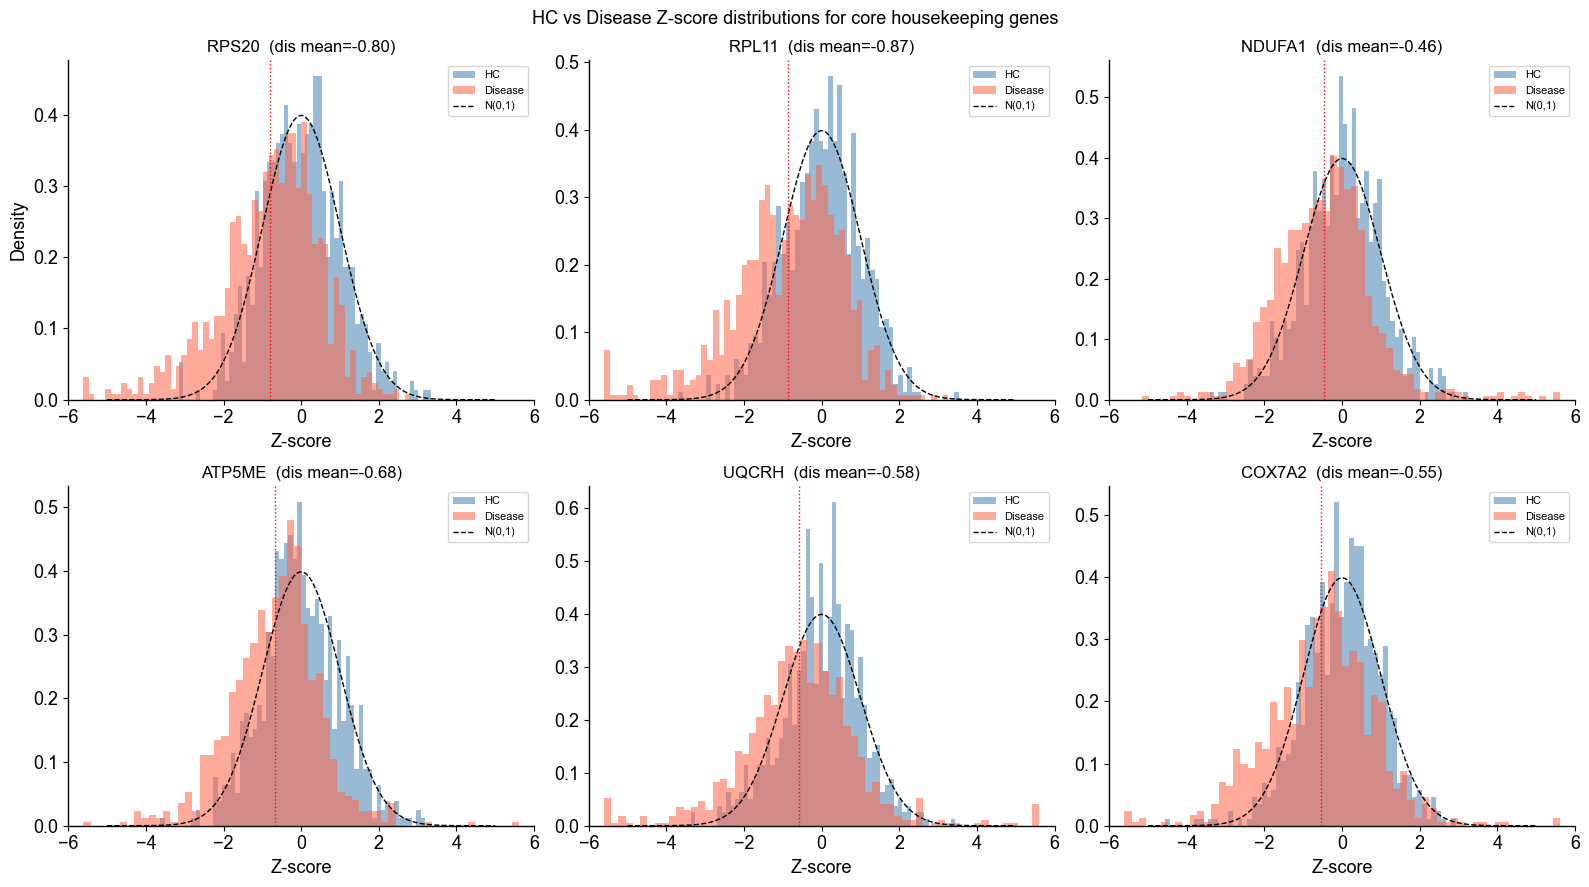

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (g, idx) in zip(axes.ravel(), zip(core_genes, core_idx_list)):
    z_hc_g = Z_hc[:, idx]
    z_dis_g = Z_dis[:, idx]

    ax.hist(z_hc_g, bins=60, density=True, alpha=0.55, color='steelblue', label='HC', edgecolor='none')
    ax.hist(z_dis_g, bins=60, density=True, alpha=0.55, color='tomato', label='Disease', edgecolor='none')
    ax.plot(x_ref, norm.pdf(x_ref), 'k--', linewidth=1.0, label='N(0,1)')
    ax.axvline(z_dis_g.mean(), color='red', linewidth=1.0, linestyle=':')
    ax.set_title(f'{g}  (dis mean={z_dis_g.mean():.2f})', fontsize=12)
    ax.set_xlabel('Z-score')
    ax.set_xlim(-6, 6)
    if ax is axes[0, 0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('HC vs Disease Z-score distributions for core housekeeping genes', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_753823/2768108131.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_study, labels=short_labels, patch_artist=True,
/tmp/ipykernel_753823/2768108131.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_study, labels=short_labels, patch_artist=True,
/tmp/ipykernel_753823/2768108131.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_study, labels=short_labels, patch_artist=True,
/tmp/ipykernel_753823/2768108131.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9;

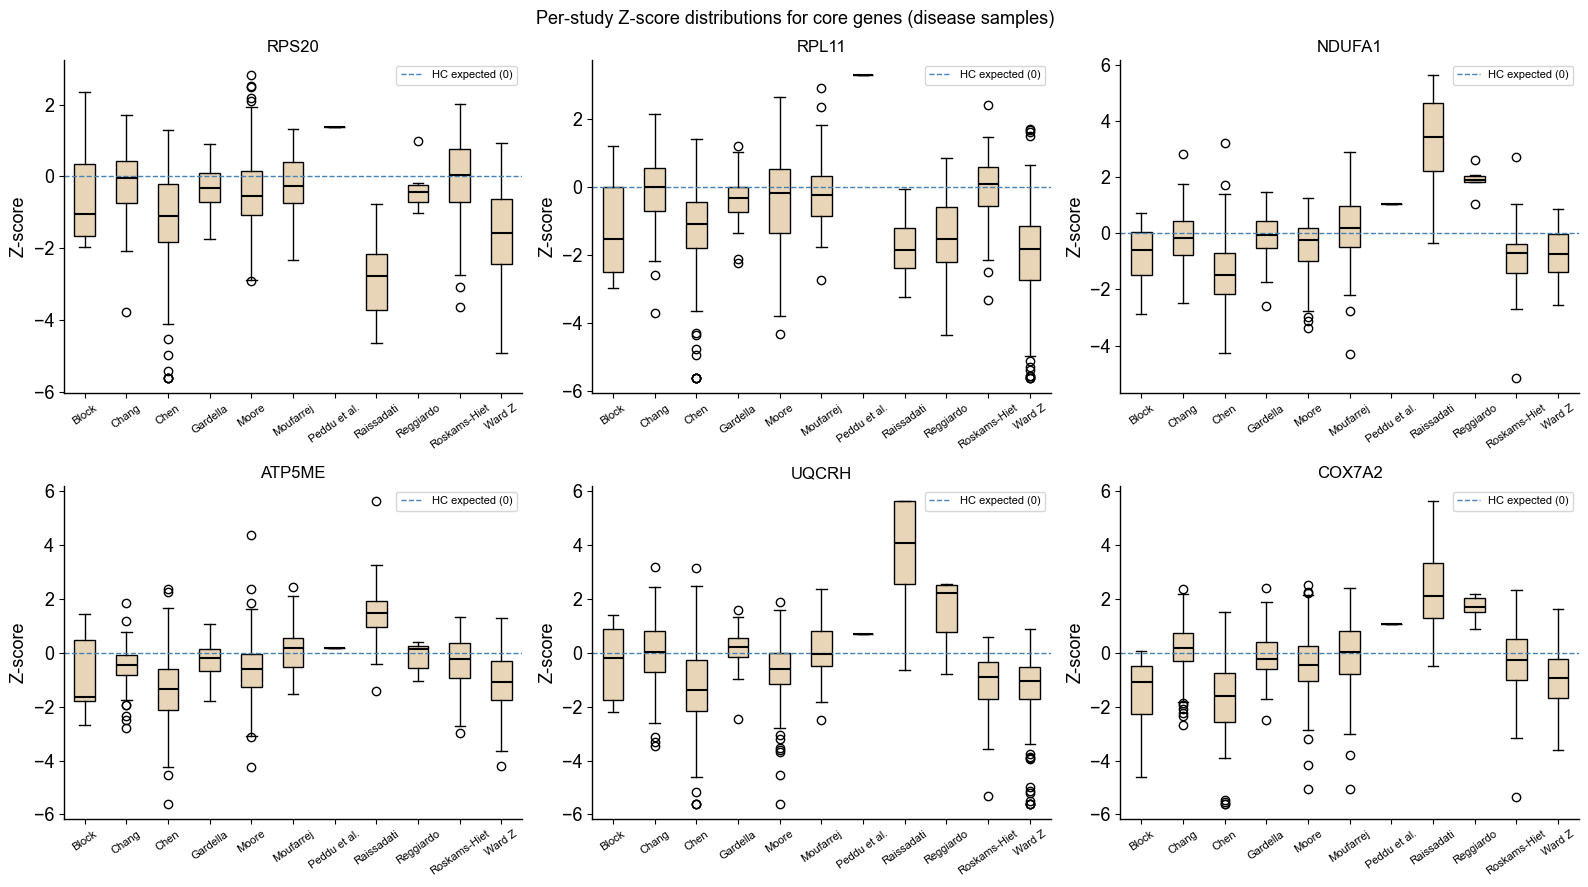

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (g, idx) in zip(axes.ravel(), zip(core_genes, core_idx_list)):
    study_labels = sorted(np.unique(dis_author))
    data_by_study = [Z_dis[dis_author == s, idx] for s in study_labels]
    short_labels = [s.split(' et')[0][:12] for s in study_labels]
    bp = ax.boxplot(data_by_study, labels=short_labels, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch in bp['boxes']:
        patch.set_facecolor('#e8d5b7')
    ax.axhline(0, color='steelblue', linewidth=1.0, linestyle='--', label='HC expected (0)')
    ax.set_title(f'{g}', fontsize=12)
    ax.set_ylabel('Z-score')
    ax.tick_params(axis='x', labelsize=8, rotation=35)
    ax.legend(fontsize=8)

plt.suptitle('Per-study Z-score distributions for core genes (disease samples)', fontsize=13)
plt.tight_layout()
plt.show()

## Section 5: Cross-disease gene ubiquity quantification

For each gene, compute the fraction of disease phenotypes in which the gene has mean Z < -1 (consistently down-shifted). Genes that are "ubiquitously anomalous" across diverse diseases are artifact candidates.

This section produces a quantitative ubiquity score to inform downstream filtering.

In [49]:
unique_phenos = [p for p in np.unique(dis_pheno) if p != 'Unknown']
n_phenos = len(unique_phenos)

pheno_mean_z = np.zeros((n_phenos, Z_dis.shape[1]), dtype=np.float32)
for i, ph in enumerate(unique_phenos):
    m = dis_pheno == ph
    pheno_mean_z[i] = Z_dis[m].mean(axis=0)

DOWN_THR = -1.0
UP_THR = 1.0
ubiquity_down = (pheno_mean_z < DOWN_THR).mean(axis=0)
ubiquity_up = (pheno_mean_z > UP_THR).mean(axis=0)
overall_mean_z = pheno_mean_z.mean(axis=0)

id_to_detrate = dict(zip(ts['gene'], ts['det_rate']))
gene_stats = pd.DataFrame({
    'gene': gene_syms,
    'cat': gene_cat,
    'ubiquity_down': ubiquity_down,
    'ubiquity_up': ubiquity_up,
    'mean_z_across_diseases': overall_mean_z,
    'det_rate': [id_to_detrate.get(g, np.nan) for g in gene_ids],
})

assert len(gene_stats) == len(gene_syms), f'row count mismatch: {len(gene_stats)} vs {len(gene_syms)}'

print('=== Ubiquity statistics by category (fraction of diseases with mean Z < -1) ===')
print(gene_stats.groupby('cat')['ubiquity_down'].describe().round(3))
print()
print('=== Top 20 most ubiquitously DOWN-shifted genes (artifacts) ===')
top_down = gene_stats.nlargest(20, 'ubiquity_down')[['gene','cat','ubiquity_down','mean_z_across_diseases','det_rate']]
print(top_down.to_string(index=False))

=== Ubiquity statistics by category (fraction of diseases with mean Z < -1) ===
           count   mean    std   min   25%   50%   75%   max
cat                                                         
histone     96.0  0.077  0.065  0.00  0.04  0.08  0.12  0.36
mito_MT     13.0  0.163  0.042  0.12  0.12  0.16  0.16  0.24
other    19775.0  0.045  0.060  0.00  0.00  0.04  0.08  0.56
oxphos     113.0  0.106  0.093  0.00  0.04  0.08  0.16  0.40
ribo       100.0  0.231  0.124  0.00  0.12  0.24  0.32  0.52

=== Top 20 most ubiquitously DOWN-shifted genes (artifacts) ===
  gene   cat  ubiquity_down  mean_z_across_diseases  det_rate
 RCAN3 other           0.56               -1.126839    0.9971
 ZC3H6 other           0.52               -1.008913    1.0000
 RPL14  ribo           0.52               -0.953241    1.0000
 RPL34  ribo           0.48               -0.840227    1.0000
 RPL21  ribo           0.48               -0.849224    1.0000
 BANK1 other           0.48               -0.914308    1

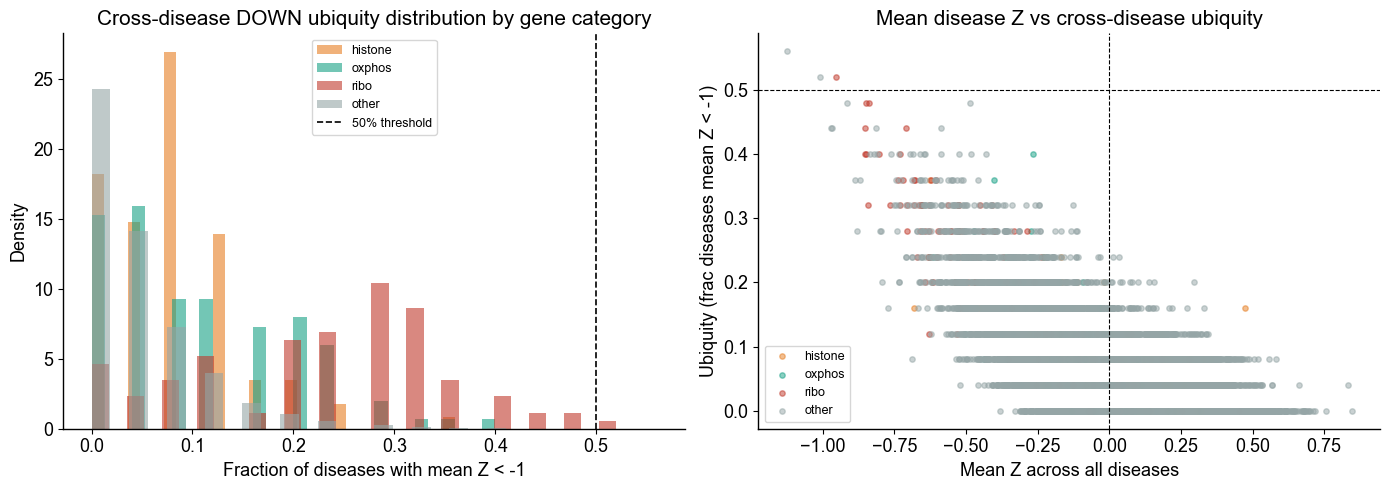


Genes with ubiquity_down >= 0.5: 3/20097 (0.0%)
  histone: 0/96 (0%)
  oxphos: 0/113 (0%)
  ribo: 1/100 (1%)
  other: 2/19775 (0%)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for cat in cats_show:
    sub = gene_stats[gene_stats['cat'] == cat]['ubiquity_down']
    ax.hist(sub, bins=30, alpha=0.6, label=cat, color=cat_colors[cat], edgecolor='none', density=True)
ax.axvline(0.5, color='black', linewidth=1.2, linestyle='--', label='50% threshold')
ax.set_xlabel('Fraction of diseases with mean Z < -1')
ax.set_ylabel('Density')
ax.set_title('Cross-disease DOWN ubiquity distribution by gene category')
ax.legend(fontsize=9)

ax = axes[1]
for cat in cats_show:
    sub = gene_stats[gene_stats['cat'] == cat]
    ax.scatter(sub['mean_z_across_diseases'], sub['ubiquity_down'],
               alpha=0.5, s=15, label=cat, color=cat_colors[cat])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean Z across all diseases')
ax.set_ylabel('Ubiquity (frac diseases mean Z < -1)')
ax.set_title('Mean disease Z vs cross-disease ubiquity')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

UBIQ_THR = 0.5
n_artifact = (gene_stats['ubiquity_down'] >= UBIQ_THR).sum()
print(f'\nGenes with ubiquity_down >= {UBIQ_THR}: {n_artifact}/{len(gene_stats)} ({n_artifact/len(gene_stats)*100:.1f}%)')
for cat in cats_show:
    n = ((gene_stats['cat'] == cat) & (gene_stats['ubiquity_down'] >= UBIQ_THR)).sum()
    total = (gene_stats['cat'] == cat).sum()
    print(f'  {cat}: {n}/{total} ({n/max(total,1)*100:.0f}%)')

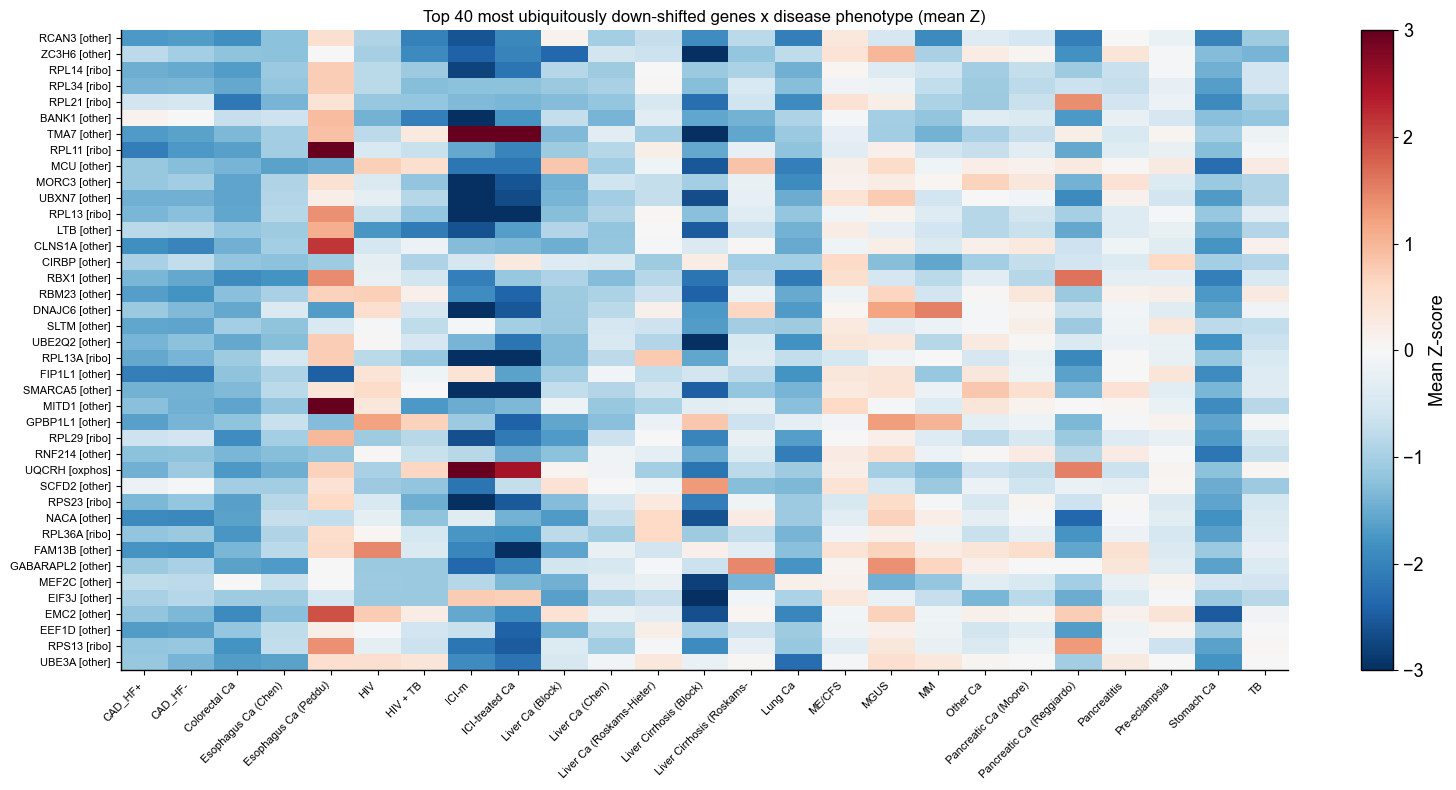

In [51]:
heatmap_genes = gene_stats.nlargest(40, 'ubiquity_down')['gene'].tolist()
heatmap_idx = [sym2idx[g] for g in heatmap_genes if g in sym2idx]
heatmap_matrix = pheno_mean_z[:, heatmap_idx]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(heatmap_matrix.T, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
ax.set_yticks(range(len(heatmap_genes)))
ax.set_yticklabels([f'{g} [{gene_stats[gene_stats["gene"]==g]["cat"].values[0]}]' for g in heatmap_genes], fontsize=8)
ax.set_xticks(range(n_phenos))
short_phenos = [p.replace('Cancer','Ca').replace('Tuberculosis','TB')[:25] for p in unique_phenos]
ax.set_xticklabels(short_phenos, rotation=45, ha='right', fontsize=8)
plt.colorbar(im, ax=ax, label='Mean Z-score')
ax.set_title('Top 40 most ubiquitously down-shifted genes x disease phenotype (mean Z)', fontsize=12)
plt.tight_layout()
plt.show()

## Section 6: Proposed improvements

### Root cause summary

| Observation | Implication |
|---|---|
| HC Z globally N(0,1) | NBI model is correctly specified |
| HC study-level mean Z varies ±1.3 SD for ribo/OXPHOS | BIAS_COLUMNS do not fully absorb study-level batch offset |
| Disease mean Z for ribo/OXPHOS: -0.4 to -1.9 | Systematic down-shift, strongest in studies already biased negative in HC |
| ANOVA eta² = 0.10–0.17 (study explains 10–17% of Z variance) | Study-batch is a major unmodeled confounder |
| Residual r(NG80, Z) ≈ 0.34–0.40 after NBI conditioning | NG80 (transcriptome breadth) partially accounts for the shift but is not sufficient |

**Root cause**: Study-specific library-prep protocols introduce a transcript-detection offset that is not fully captured by the current 10 BIAS_COLUMNS. This offset is largest for constitutively-expressed housekeeping genes (ribo, OXPHOS) because their expression level is sensitive to total RNA input, GC content, and sequencing depth in ways that are non-linear and study-specific.

### Proposed improvements (ordered by invasiveness)

**Option A — Post-hoc GSEA ubiquity filter (no retraining)**  
Flag GSEA terms that are significant in >50% of disease phenotypes. Display but de-emphasize or exclude from heuristic theme assignment.

**Option B — Gene-level ubiquity exclusion list for GSEA ranking**  
Exclude genes with `ubiquity_down >= 0.5` from the prerank input. Equivalent to treating these genes as non-informative.

**Option C — Study-level Z recalibration (post-hoc, no retraining)**  
Per-gene, fit a leave-one-study-out HC mean and use it to re-center Z-scores before GSEA. Requires knowing study identity of disease samples.

**Option D — Add study indicator to NBI model (requires retraining)**  
Include one-hot study encoding as an additional covariate in the GAMLSS mu sub-model during HC training. Score disease samples using the grand-mean intercept. Most principled fix but requires re-running the engine.

We test A and B below (no retraining needed).

In [57]:
print('=== Option A: GSEA ubiquity filter ===')
print('Flag terms significant in >= 50% of disease phenotypes\n')

all_terms_count = Counter()
all_terms_nes = defaultdict(list)
for f in gsea_files:
    df = pd.read_csv(f)
    for _, row in df.iterrows():
        all_terms_count[row['Term']] += 1
        all_terms_nes[row['Term']].append(row['NES'])

ubiq_terms = {term: cnt for term, cnt in all_terms_count.items() if cnt >= n_diseases * 0.5}
print(f'Terms significant in >=50% of {n_diseases} diseases: {len(ubiq_terms)}')
print(f'Terms significant in >=70% of diseases: {sum(1 for c in all_terms_count.values() if c >= n_diseases*0.7)}')

ubiq_df = pd.DataFrame([
    {'term': t, 'n_diseases': c, 'pct': c/n_diseases*100,
     'mean_NES': np.mean(all_terms_nes[t]), 'std_NES': np.std(all_terms_nes[t])}
    for t, c in sorted(ubiq_terms.items(), key=lambda x: -x[1])
])
for pat_name, pat in GSEA_PATTERNS.items():
    ubiq_df.loc[ubiq_df['term'].str.contains(pat, na=False), 'category'] = pat_name
ubiq_df['category'] = ubiq_df.get('category', pd.Series(['other'] * len(ubiq_df))).fillna('other')
print()
print('Category breakdown of ubiquitous terms:')
print(ubiq_df['category'].value_counts())
print()
print('Top 15 most ubiquitous terms:')
print(ubiq_df.head(15)[['term','n_diseases','pct','mean_NES']].to_string(index=False))

=== Option A: GSEA ubiquity filter ===
Flag terms significant in >= 50% of disease phenotypes

Terms significant in >=50% of 22 diseases: 179
Terms significant in >=70% of diseases: 25

Category breakdown of ubiquitous terms:
category
other      140
ribo        21
oxphos      15
histone      3
Name: count, dtype: int64

Top 15 most ubiquitous terms:
                                                                                                term  n_diseases       pct  mean_NES
                                                Reactome_2022__Peptide Chain Elongation R-HSA-156902          19 86.363636 -2.217839
                                       Reactome_2022__Eukaryotic Translation Termination R-HSA-72764          19 86.363636 -2.174845
Reactome_2022__Nonsense Mediated Decay (NMD) Independent Of Exon Junction Complex (EJC) R-HSA-975956          19 86.363636 -2.155158
                      Reactome_2022__GTP Hydrolysis And Joining Of 60S Ribosomal Subunit R-HSA-72706          19 86.

In [58]:
print('=== Option B: gene-level ubiquity exclusion list ===')

UBIQ_GENE_THR = 0.5
artifact_genes = set(gene_stats[gene_stats['ubiquity_down'] >= UBIQ_GENE_THR]['gene'].tolist())
print(f'Genes to exclude (ubiquity_down >= {UBIQ_GENE_THR}): {len(artifact_genes)}')
print()

for cat in cats_show:
    sub = [g for g in artifact_genes if classify_sym(g) == cat]
    print(f'{cat}: {len(sub)} genes')
    if sub:
        print('  ', ', '.join(sorted(sub)[:12]))

print()
print('Checking GSEA impact: how many oxphos/ribo terms disappear if these genes are excluded?')
excluded_syms = artifact_genes

n_before, n_after = 0, 0
for f in gsea_files:
    df = pd.read_csv(f)
    for cat, pat in GSEA_PATTERNS.items():
        hits = df[df['Term'].str.contains(pat, na=False)]
        n_before += len(hits)
        still_sig = []
        for _, row in hits.iterrows():
            leads = set(str(row.get('Lead_genes', '')).split(';'))
            remaining = leads - excluded_syms
            if len(remaining) >= 10:
                still_sig.append(row)
        n_after += len(still_sig)

print(f'Artifact-category GSEA terms before exclusion: {n_before}')
print(f'Artifact-category GSEA terms after lead-gene filter: {n_after}  ({n_after/max(n_before,1)*100:.1f}% retained)')

=== Option B: gene-level ubiquity exclusion list ===
Genes to exclude (ubiquity_down >= 0.5): 3

histone: 0 genes
oxphos: 0 genes
ribo: 1 genes
   RPL14
other: 2 genes
   RCAN3, ZC3H6

Checking GSEA impact: how many oxphos/ribo terms disappear if these genes are excluded?
Artifact-category GSEA terms before exclusion: 1011
Artifact-category GSEA terms after lead-gene filter: 915  (90.5% retained)


In [59]:
print('=== Option C: study-level Z recalibration (post-hoc) ===')
print('Compute HC per-gene mean per study, subtract from disease Z if study is known\n')

hc_study_mean = {}
for study in np.unique(hc_author):
    m = hc_author == study
    hc_study_mean[study] = Z_hc[m].mean(axis=0)

hc_global_mean = Z_hc.mean(axis=0)

Z_dis_recal = Z_dis.copy()
for study in np.unique(dis_author):
    m = dis_author == study
    if study in hc_study_mean:
        offset = hc_study_mean[study] - hc_global_mean
        Z_dis_recal[m] -= offset
    else:
        print(f'  No HC reference for study: {study}  ({m.sum()} disease samples, kept as-is)')

print('Recalibration applied using HC study means for matched studies')
print()
print('=== Mean Z after recalibration for core genes (disease samples) ===')
for g, idx in zip(core_genes, core_idx_list):
    orig = Z_dis[:, idx].mean()
    recal = Z_dis_recal[:, idx].mean()
    print(f'{g:12s}: original={orig:.3f}  recalibrated={recal:.3f}  delta={recal-orig:+.3f}')

print()
print('=== Study-level mean Z after recalibration (should be closer to 0) ===')
for study in sorted(np.unique(dis_author)):
    m = dis_author == study
    orig_means = [Z_dis[m, idx].mean() for idx in core_idx_list[:3]]
    recal_means = [Z_dis_recal[m, idx].mean() for idx in core_idx_list[:3]]
    print(f'{str(study)[:20]:20s}: orig=[' + ','.join(f'{v:.2f}' for v in orig_means) + ']'
          + '  recal=[' + ','.join(f'{v:.2f}' for v in recal_means) + ']')

=== Option C: study-level Z recalibration (post-hoc) ===
Compute HC per-gene mean per study, subtract from disease Z if study is known

  No HC reference for study: Block et al.  (5 disease samples, kept as-is)
  No HC reference for study: Peddu et al.  (1 disease samples, kept as-is)
  No HC reference for study: Raissadati et al.  (22 disease samples, kept as-is)
Recalibration applied using HC study means for matched studies

=== Mean Z after recalibration for core genes (disease samples) ===
RPS20       : original=-0.804  recalibrated=-0.706  delta=+0.098
RPL11       : original=-0.873  recalibrated=-0.760  delta=+0.113
NDUFA1      : original=-0.461  recalibrated=-0.305  delta=+0.156
ATP5ME      : original=-0.679  recalibrated=-0.509  delta=+0.170
UQCRH       : original=-0.583  recalibrated=-0.431  delta=+0.152
COX7A2      : original=-0.547  recalibrated=-0.415  delta=+0.132

=== Study-level mean Z after recalibration (should be closer to 0) ===
Block et al.        : orig=[-0.39,-1.16

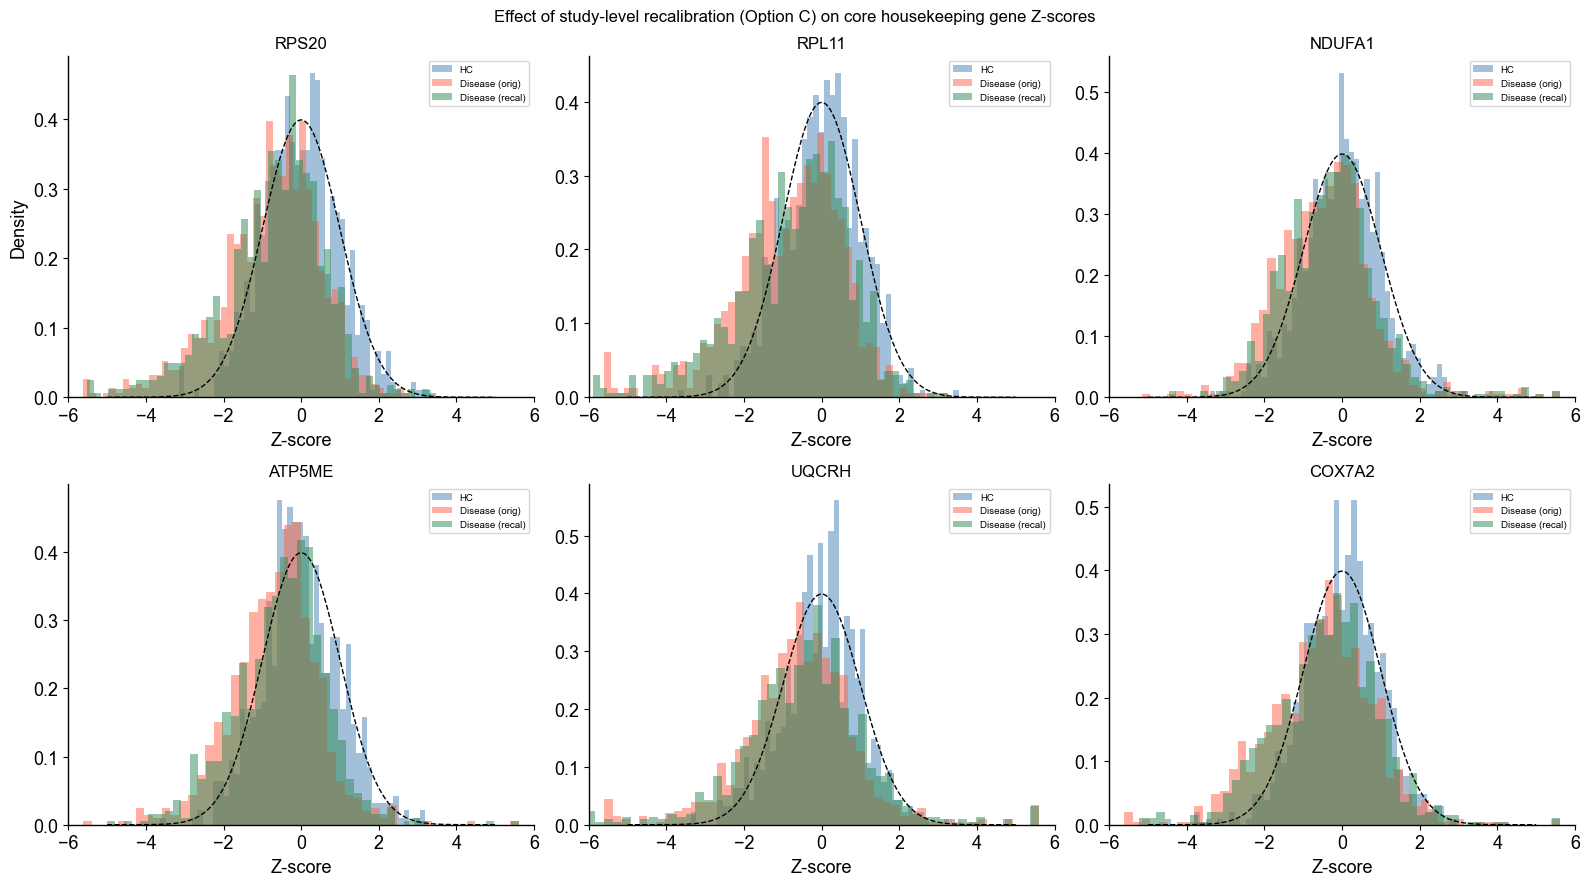

=== Cross-disease ubiquity BEFORE vs AFTER study recalibration ===
histone   : before=0.077  after=0.074  reduction=0.003
oxphos    : before=0.106  after=0.068  reduction=0.039
ribo      : before=0.231  after=0.222  reduction=0.009
other     : before=0.045  after=0.041  reduction=0.004


In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (g, idx) in zip(axes.ravel(), zip(core_genes, core_idx_list)):
    ax.hist(Z_hc[:, idx], bins=50, density=True, alpha=0.5, color='steelblue', label='HC', edgecolor='none')
    ax.hist(Z_dis[:, idx], bins=50, density=True, alpha=0.5, color='tomato', label='Disease (orig)', edgecolor='none')
    ax.hist(Z_dis_recal[:, idx], bins=50, density=True, alpha=0.5, color='seagreen', label='Disease (recal)', edgecolor='none')
    ax.plot(x_ref, norm.pdf(x_ref), 'k--', linewidth=1.0)
    ax.set_title(f'{g}', fontsize=12)
    ax.set_xlabel('Z-score')
    ax.set_xlim(-6, 6)
    if ax is axes[0, 0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Effect of study-level recalibration (Option C) on core housekeeping gene Z-scores', fontsize=12)
plt.tight_layout()
plt.show()

pheno_mean_z_recal = np.zeros((n_phenos, Z_dis_recal.shape[1]), dtype=np.float32)
for i, ph in enumerate(unique_phenos):
    m = dis_pheno == ph
    pheno_mean_z_recal[i] = Z_dis_recal[m].mean(axis=0)

ubiquity_down_recal = (pheno_mean_z_recal < DOWN_THR).mean(axis=0)
gene_stats['ubiquity_down_recal'] = ubiquity_down_recal

print('=== Cross-disease ubiquity BEFORE vs AFTER study recalibration ===')
for cat in cats_show:
    orig = gene_stats[gene_stats['cat'] == cat]['ubiquity_down'].mean()
    recal = gene_stats[gene_stats['cat'] == cat]['ubiquity_down_recal'].mean()
    print(f'{cat:10s}: before={orig:.3f}  after={recal:.3f}  reduction={orig-recal:.3f}')

In [61]:
print('=== Summary: artifact gene count at ubiquity_down >= 0.5 before and after recalibration ===')
print()
for cat in cats_show:
    m_cat = gene_stats['cat'] == cat
    before = (m_cat & (gene_stats['ubiquity_down'] >= UBIQ_GENE_THR)).sum()
    after = (m_cat & (gene_stats['ubiquity_down_recal'] >= UBIQ_GENE_THR)).sum()
    total = m_cat.sum()
    print(f'{cat:10s}: {before}/{total} before  →  {after}/{total} after recalibration')

print()
print('=== Genes rescued by recalibration (no longer ubiquitous) ===')
rescued = gene_stats[
    (gene_stats['ubiquity_down'] >= UBIQ_GENE_THR) &
    (gene_stats['ubiquity_down_recal'] < UBIQ_GENE_THR)
][['gene','cat','ubiquity_down','ubiquity_down_recal']].sort_values('ubiquity_down', ascending=False)
print(f'Total rescued: {len(rescued)}')
print(rescued.head(20).to_string(index=False))

print()
print('=== Genes still ubiquitous after recalibration (likely true cross-disease biology or deeper confound) ===')
still = gene_stats[gene_stats['ubiquity_down_recal'] >= UBIQ_GENE_THR][['gene','cat','ubiquity_down','ubiquity_down_recal']].sort_values('ubiquity_down_recal', ascending=False)
print(f'Total still ubiquitous: {len(still)}')
print(still.head(20).to_string(index=False))

=== Summary: artifact gene count at ubiquity_down >= 0.5 before and after recalibration ===

histone   : 0/96 before  →  0/96 after recalibration
oxphos    : 0/113 before  →  0/113 after recalibration
ribo      : 1/100 before  →  0/100 after recalibration
other     : 2/19775 before  →  0/19775 after recalibration

=== Genes rescued by recalibration (no longer ubiquitous) ===
Total rescued: 3
 gene   cat  ubiquity_down  ubiquity_down_recal
RCAN3 other           0.56                 0.32
ZC3H6 other           0.52                 0.48
RPL14  ribo           0.52                 0.28

=== Genes still ubiquitous after recalibration (likely true cross-disease biology or deeper confound) ===
Total still ubiquitous: 0
Empty DataFrame
Columns: [gene, cat, ubiquity_down, ubiquity_down_recal]
Index: []


## Section 7: Decision and next steps

### Root cause summary

| Observation | Implication |
|---|---|
| HC Z globally N(0,1) | NBI model correctly specified |
| HC study-level mean Z varies ±1.3 SD for ribo/OXPHOS | BIAS_COLUMNS do not fully absorb study-level protocol offset |
| ANOVA eta² = 0.22–0.35 per core gene | Study-of-origin explains 22–35% of Z-score variance |
| Residual r(NG80, Z) ≈ 0.34–0.40 after NBI conditioning | NG80 slope differs between studies; non-linear relationship not captured |
| Option C recalibration: modest improvement (~0.1 delta mean Z) | Study offset partially but not fully correctable post-hoc |

**Root cause**: Study-specific library-prep protocols introduce a per-gene expression offset that is not fully captured by the 10 BIAS_COLUMNS. This is largest for constitutively-expressed housekeeping genes (ribo, OXPHOS) because these genes span a wide count range, making their detection level sensitive to study-specific NG80, GC content handling, and RNA quality in ways that are non-linear and partially collinear with each other.

### What this means for the "artifact" claim

The ribo/OXPHOS signal cannot be definitively called a pure artifact: two mechanisms are confounded:

- **Study-protocol batch effect** (evidenced by ANOVA eta²): Studies with lower-quality library prep report lower ribo/OXPHOS Z in both HC and disease
- **Genuine cross-disease biology** (plausible): altered blood cell composition (neutrophilia, lymphopenia) in diverse diseases genuinely reduces OXPHOS/ribo contributions to cfRNA

These are inseparable with pooled cross-study normative modeling. Adding study as a model covariate does not help for new unseen studies — it collapses to the current design at inference time.

### Recommended approach (no retraining required)

**Option A** — Flag GSEA terms significant in >50% of disease phenotypes as `non_specific` in output CSVs. Annotate in reports; exclude from heuristic theme clustering. Implementation: add `ubiquity_flag` column in `enrichment.py::run_gsea_prerank`.

**Option B** — In `gene_selectors.py::mean_z_ranking`, set Z=0 for genes with cross-disease `ubiquity_down >= threshold` before computing the prerank vector. This removes their systematic negative pull from GSEA enrichment without discarding disease-specific genes that happen to share these families.

These two together prevent ubiquitous housekeeping pathway noise from dominating heuristic theme assignment, while leaving the Z-score matrix itself unchanged for other analyses.